Dr. Xiao Li xiaoli@pku.edu.cn, 2026 Summer 

**AI for Cell Image Analysis** <a id=0> </a>

# <span style="font-size:30px"> Part 2. Introduction to Deep Learning</span>

This notebook is designed for students with zero background in deep learning, progressively introducing core **deep learning** concepts through five dataset-network combinations:
- entry-level: handwritten digit recognition using MLP + MNIST
- advancing to: blood-cell image classification using CNN + BloodMNIST
---

## <span style="font-size:25px"> Task 0: Environment Setup </span>

Installing necessary Python libraries

In [61]:
# Install PyTorch and other dependencies for image processing
%uv pip install torch torchvision torchaudio
# If you have GPU support, you can try the GPU version by uncommenting the next line.
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%uv pip install tqdm medmnist


Note: you may need to restart the kernel to use updated packages.


E:\G2.2\aichem\p5\.venv\Scripts\python.exe: No module named uv


Note: you may need to restart the kernel to use updated packages.


E:\G2.2\aichem\p5\.venv\Scripts\python.exe: No module named uv


---

## <span style="font-size:25px"> Task 1: MNIST Classfication </span>

`MNIST` (Modified National Institute of Standards and Technology) is a handwritten digit recognition dataset, widely regarded as the "Hello World" of computer vision. The dataset contains 70,000 grayscale images of 28×28 pixels, with 60,000 for training and 10,000 for testing. Each image represents a single handwritten digit from 0 to 9. MNIST has become a classic introductory dataset for deep learning due to its simplicity and standardization.

### 1.1 Imports

This part import required modules.

In [62]:
#pip install --upgrade typing-extensions

In [63]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm #tqdm is a Python library for progress bar

This part automatically detect if you have GPU available. The program will use  GPU if available, otherwise will use CPU.

In [64]:
# Automatic device detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


### 1.2 Load Data

In [65]:
import PIL
from PIL import Image

In [66]:
# Load the raw MNIST dataset
mnist_train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_test_raw = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=None)

We use the _root_ parameter to define where to save the data. "./" stands for the current working directory of this notebook. You could open your fold containing this notebook to see a new folder called "mnistdata" is created: ./data/MNIST/raw <br>

The _train_ parameter is set to True because we are initializing the MNIST training dataset, and is set to False if we are saving the testing dataset. <br>

The _download_ parameter is set to True because we want to download it if it’s not already present in our data folder. <br>

The _transform_ parameter is set to None because we don’t want to apply any image manipulation transforms at this time. <br>

We can see that each element in the dataset contains a tuple. A tuple is like a list with fixed value. THe tuple contains a PIL.image object and a target lable（0~9).

**Explore the Data**🔍 <br>

In [67]:
#explore the dataset
print(f"the data type of mnist_train_raw is: {type(mnist_train_raw)}")
print(f"Training set size: {len(mnist_train_raw)}")
print(f"Testing set size: {len(mnist_test_raw)}")

#TODO set to a certain index to view the data
n = 0
print(f"the type nth element: {type(mnist_train_raw[n])}") 
print(f"the nth element in the raw training set: {mnist_train_raw[n]}") 

the data type of mnist_train_raw is: <class 'torchvision.datasets.mnist.MNIST'>
Training set size: 60000
Testing set size: 10000
the type nth element: <class 'tuple'>
the nth element in the raw training set: (<PIL.Image.Image image mode=L size=28x28 at 0x22627107D90>, 5)


In [68]:
#save the PIL image object and corresponding lable 
#for nth element in two seperate variables
image_n,label_n = mnist_train_raw[n]
print(f"the image format, size and mode for nth image is: {image_n.format},{image_n.size},{image_n.mode}") 
print(f"the label for nth image is: {label_n}") 
image_n #show image_n

the image format, size and mode for nth image is: None,(28, 28),L
the label for nth image is: 5


PIL.image format can be 'PNG, 'JPEG' etc. "None" format is default for a PIL.image object. image.mode 'L' means grayscale. 

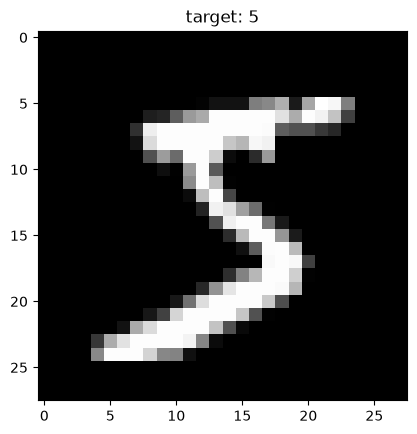

the size of pixel: (28, 28)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [69]:
# convert an image object to an numpy array
pixels = np.array(image_n)  

# show the array as image
plt.imshow(pixels,cmap="gray")
plt.title(f"target: {label_n}")
plt.show()
#
print(f"the size of pixel: {pixels.shape}")  #total number of pixels = 28x28
pixels

In [70]:
# get pixel data (as Tuples) from PIL.image object
# TODO set pixel coordinate: x=column, y=row  
x = 0
y = 0
pixel = image_n.getpixel((x, y)) 
print(pixel)  # 0 for black and 225 for white 


0


To train a neural network model, the data for the images need to be standardized/normalized and store in tensors. 

📘**Tensor** is a generalization of scalars, vectors, and matrices in mathematics.

| Tensor Order | Example            | Shape       | Description         |
| ------------ | ------------------ | ----------- | ------------------- |
| 0D           | `3.14`             | `()`        | Scalar              |
| 1D           | `[1, 2, 3]`        | `(3,)`      | Vector              |
| 2D           | `[[1, 2], [3, 4]]` | `(2, 2)`    | Matrix              |
| 3D+          | `[[[...]]]`        | `(n, m, k)` | Tensor (3D or more) |


In machine learning, especially in image processing, tensors are used to represent data like images, batches of images, and so on. 

The terms tensor and NumPy array are similar, but they  have different capabilities, especially in deep learning frameworks like TensorFlow or PyTorch. A tensor is a more powerful and flexible structure than a plain NumPy array, especially when training models on GPUs or using automatic differentiation. All tensors can be thought of as n-dimensional arrays, but not all n-dimensional arrays (like np.array) are tensors in the deep learning sense.

Pytorch can convert PIL.image object to tensor through <a style = 'color:purple'> transform.ToTensor() </a> setting. 


In [71]:
#transform MNIST raw data to tensor
mnist_train_tensor = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Get all the image pixel data
loader = DataLoader(mnist_train_tensor, batch_size=60000, shuffle=False)
images, _ = next(iter(loader))  # images shape: [60000, 1, 28, 28]


In [72]:
print(images.shape)
#N=60000 number of images
#C=1, number of channels, grayscale only 1 channel
#H=28, height, number of rows
#W=28, width, number of columns

torch.Size([60000, 1, 28, 28])


In [73]:
# Flatten to [N, C*H*W]
#images = images.view(images.size(0), -1)  # shape: [60000, 784]
images = images.reshape(images.size(0), -1)  # shape: [60000, 784]
#print(images.shape)

# Compute mean and std
mean = images.mean()
std = images.std()

print(f"Mean: {mean:.4f}")
print(f"Std: {std:.4f}")

Mean: 0.1307
Std: 0.3081


The raw data ontains pixel grayscale values ranging from 0 to 225 and need to be normalized to the range `[0, 1]`

- Standardizes the pixel values using the formula:

    $ \text{normalized value} = \frac{\text{pixel} - \mu}{\sigma} $

- In this case: $ \mu $ = 0.1307, $ \sigma $ = 0.3081. These are the precomputed mean and standard deviation of the MNIST dataset.


In [74]:
# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load normalized data as tensors
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)


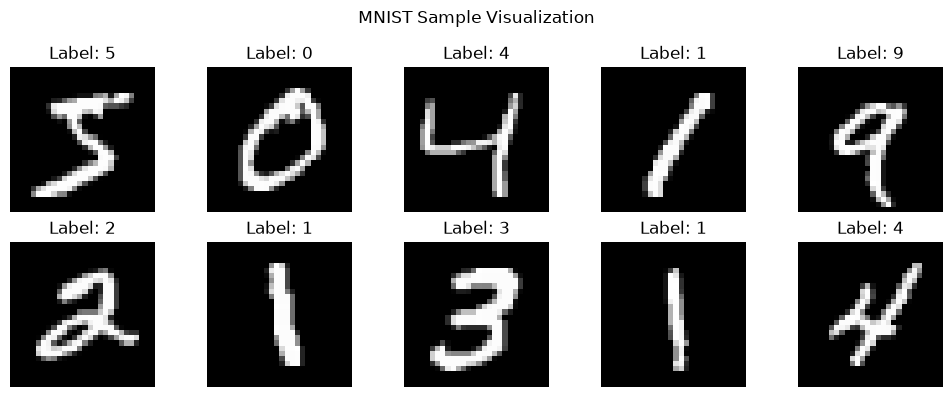

In [75]:
# Create data loaders
# Load parts of the data (32 iamges)
train_loader = DataLoader(mnist_train, batch_size=32, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=32, shuffle=False)

# Visualize data samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    row = i // 5
    col = i % 5
    image, label = mnist_train[i]
    axes[row, col].imshow(image.squeeze(), cmap='gray', interpolation='none')
    axes[row, col].set_title(f'Label: {label}')
    axes[row, col].axis('off')

plt.suptitle('MNIST Sample Visualization')
plt.tight_layout()
plt.show()

In [76]:
print(f"the nth element in the raw training set: {mnist_train_raw[n]}") 
print(f"the nth element in the transformed training set:\n {mnist_train[n]}") 

the nth element in the raw training set: (<PIL.Image.Image image mode=L size=28x28 at 0x226270771B0>, 5)
the nth element in the transformed training set:
 (tensor([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0

In [77]:
# Display dataset information
print("\nMNIST Dataset Information:")
print(f"Image shape: {mnist_train[n][0].shape}")
print(f"Number of classes: 10 (digits 0-9)")


MNIST Dataset Information:
Image shape: torch.Size([1, 28, 28])
Number of classes: 10 (digits 0-9)


https://www.datascienceweekly.org/tutorials/pytorch-mnist-load-mnist-dataset-from-pytorch-torchvision 

### 1.3 Define MLP Model

`Multilayer Perceptron (MLP)` is the most basic feedforward neural network architecture, consisting of an **input layer**, one or more **hidden layers**, and an **output layer**. Each layer is fully connected to the next layer, hence also called **fully connected (FC)** networks or dense networks. Each neuron in an MLP uses a _nonlinear activation function_, enabling the network to learn complex nonlinear mappings.

<img src="./img/MLP_mnist.png" alt="sigmoid function" style="width: 600px"/> </br>
**Figure 1**. An example multilayer perceptron (MLP) archetecture for MNIST handwritten digits classification.

Figure 1 illustrates a typical MLP archetecture. Let's go through the codes used for building a simple MLP.

 for the MNIST handwritten digits classification problem, the number of features for the input and output layers are fixed.

- _<font color='purple'>input layer</font>_</br>
    Number of input features = 28x28 = 784 </br> 
    <font face="Courier New"> nn.Flatten()</font> can be used to convert 2D images (28x28 pixels) into 1D vectors (784 elements). 
- _<font color='purple'>output layer</font>_</br>
    Number of output features = 10 </br>
    The MLP should outputs the classification results which fall into 10 categories of digits: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9. 
- _<font color='purple'>Hidden layers</font>_ </br>
    MLP should have at least one hidden layer. The archetecture shown in figure 1 has two hidden layers. <font face="Courier New">nn.Dropout(<font color='blue'>p</font>) </font> helps prevent overfitting to the training data. </br>
    To define a MLP as shown, we can use codes like below:</br>
    <font face="Courier New">
        self.flatten = nn.Flatten() </br>
        self.fc1 = nn.Linear(784, <font color='blue'>X1</font>) </br>
        self.fc2 = nn.Linear(128, <font color='blue'>X2</font>) </br>
        self.fc3 = nn.Linear(<font color='blue'>X2</font>, 10) </br>
        self.dropout = nn.Dropout(<font color='blue'>p</font>) </br>
    </font>

After each fully connected layer (e.g., fc1) a nonlinear function should be introduced after each hidden layer to activate the neural network. Common nonlinear functions are `ReLu` and `sigmoid` function. </br>
Example code is </br>
<font face="Courier New">x = torch.relu(self.fc1(x)) </font>


**TODO**: Define your own MLP (SimpleMLP) by specifying X1，X2 (X3 ...) and p. </br>
    Note: MNIST dataset is a relatively simple and robust dataset, and the classification results are not very sensitive to the network archetecture. You can try to have one layer, two layers, three or even more layers and see the results. A recommended p value is 0.2, meaning dropping out 20% of features after each fc. Dropout is not necessary in this problem though. 


In [78]:
#Defines neural network class called SimpleMLP that inherits from PyTorch's base nn.Module class
class SimpleMLP(nn.Module): 
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # TODO: Define the network layers
        # Hint: You need Flatten, Linear layers, and Dropout
        
        # 定义网络层
        self.flatten = nn.Flatten()  # 将输入展平
        # 定义全连接层（线性层）
        self.fc1 = nn.Linear(784, 128)   # 输入: 8x8=64, 输出: 64
        self.fc2 = nn.Linear(128, 64)       # 64 -> 32
        self.fc3 = nn.Linear(64, 10)       # 32 -> 10 (输出10个数字类)
        # 定义 Dropout 层（防止过拟合）
        self.dropout = nn.Dropout(0.2)     # 20% 的神经元随机失活
        # 定义激活函数
        self.relu = nn.ReLU()
        # TODO end
        
    def forward(self, x):
        # TODO: Define the forward pass
        # Hint: Apply flatten, then linear layers with ReLU and dropout
        
        # 前向传播
        x = self.flatten(x)           # 展平: (batch_size, 64)
        x = self.fc1(x)               # 第一层: (batch_size, 64)
        x = self.relu(x)              # ReLU 激活
        x = self.dropout(x)           # Dropout
        
        x = self.fc2(x)               # 第二层: (batch_size, 32)
        x = self.relu(x)              # ReLU 激活
        x = self.dropout(x)           # Dropout
        x = self.fc3(x)               # 输出层: (batch_size, 10)
        # 注意: 通常不在这里加 softmax，因为损失函数会处理
        return x
        # TODO end

In [79]:
# Create model instance
model = SimpleMLP()
print("MLP Model Structure:")
print(model)

# Calculate total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal number of parameters: {total_params:,}")

MLP Model Structure:
SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

Total number of parameters: 109,386


The exact parameter count for this SimpleMLP is calculated as:

fc1 layer: 784×128 + 128 = 100,480 <br>
fc2 layer: 128×64 + 64 = 8,256 <br>
fc3 layer: 64×10 + 10 = 650 <br>

Total parameters = 100,480 + 8,256 + 650 = 109,386

Simple MLP has a common pattern in the network architecture:

**input layer → hidden layer(+non-linear activaton) → dropout → ...→ hidden layer(+non-linear activaton) → dropout → output layer**


### 1.4 Define Training and Evaluation Functions

In [80]:
#Defines a function to train the model for one epoch
def train_one_epoch(model, train_loader, criterion, optimizer, epoch):
    model.train() #set the model to training mode (enables dropout, batch norm updates)
    #initializes counters: 
    total_loss = 0 #cumulative loss
    correct = 0 #correct predictions
    total = 0 #total samples processed
    
    #creates a progress bar with description showing current epoch
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1} [Training]', leave=False)
    
    for data, target in pbar:
        #  Move data to device for GPU support
        # Hint: Use .to(device) for both data and target
        data, target = data.to(device), target.to(device)
        # end
        
        # Implement the training step
        # Hint: zero_grad, forward pass, loss calculation, backward, optimizer step
        optimizer.zero_grad() #clears old gradients from previous batch
        output = model(data) #forward pass: computes model predictions
        loss = criterion(output, target) #calculates loss between predictions and true labels
        loss.backward() #backward pass: computes gradients
        optimizer.step() #updates model parameters using optimizer
        # end
        
        # Calculate statistics
        total_loss += loss.item()
        _, predicted = torch.max(output.data, 1) #gets predicted class (index with highest score)
        total += target.size(0) #counts total samples in batch
        correct += (predicted == target).sum().item() #counts correct predictions in batch
        
        # Update progress bar with current batch loss and accuracy
        current_acc = 100 * correct / total
        pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{current_acc:.2f}%'})
    
    #Calculates epoch average loss and accuracy
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [81]:
#defines evaluation function with similar parameters as training
def evaluate(model, test_loader, criterion, epoch):
    model.eval() #sets model to evaluation mode (disables dropout, fixes batch norm)
    #initializes same counters as training
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(test_loader, desc=f'Epoch {epoch+1} [Validation]', leave=False)
    
    with torch.no_grad():
        for data, target in pbar:
            # Move data to device for GPU support
            data, target = data.to(device), target.to(device)
            # end
            
            # Implement the evaluation step
            # Hint: forward pass and loss calculation (no gradients needed)
            output = model(data)
            loss = criterion(output, target)
            #  end
            
            total_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            # Update progress bar
            current_acc = 100 * correct / total
            pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{current_acc:.2f}%'})

    avg_loss = total_loss / len(test_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy
    

### 1.5 Train the Model

In [82]:
#  Move model to device for GPU support
# Hint: Use model.to(device)
model = model.to(device)
# end

# TODO: Define loss function and optimizer
# Hint: Use CrossEntropyLoss and Adam optimizer
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)
# TODO end

# Record training progress
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

epochs = 5
print("Starting training...")
print(f"Model will train on: {device}")

# Add main training loop with epoch progress
# Hint: Use tqdm for epoch progress and time tracking
start_time = time.time()

for epoch in tqdm(range(epochs), desc="Overall Progress"):
    epoch_start = time.time()
    
    # Train for one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch)
    test_loss, test_acc = evaluate(model, test_loader, criterion, epoch)
    
    # Record metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    epoch_time = time.time() - epoch_start
    
    print(f'Epoch [{epoch+1}/{epochs}] - Time: {epoch_time:.1f}s')
    print(f'  Training   - Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%')
    print(f'  Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc:.2f}%')
    print('-' * 50)

total_time = time.time() - start_time
print(f"Training completed on {device}! Total time: {total_time:.1f}s")

Starting training...
Model will train on: cpu


Overall Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 [Training]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1 [Validation]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [1/5] - Time: 24.4s
  Training   - Loss: 0.3048, Accuracy: 90.85%
  Validation - Loss: 0.1244, Accuracy: 96.08%
--------------------------------------------------


Epoch 2 [Training]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2 [Validation]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [2/5] - Time: 42.1s
  Training   - Loss: 0.1574, Accuracy: 95.28%
  Validation - Loss: 0.1015, Accuracy: 97.00%
--------------------------------------------------


Epoch 3 [Training]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 3 [Validation]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [3/5] - Time: 27.3s
  Training   - Loss: 0.1277, Accuracy: 96.15%
  Validation - Loss: 0.0853, Accuracy: 97.55%
--------------------------------------------------


Epoch 4 [Training]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 4 [Validation]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [4/5] - Time: 61.7s
  Training   - Loss: 0.1137, Accuracy: 96.51%
  Validation - Loss: 0.0799, Accuracy: 97.66%
--------------------------------------------------


Epoch 5 [Training]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 5 [Validation]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [5/5] - Time: 23.0s
  Training   - Loss: 0.1029, Accuracy: 96.86%
  Validation - Loss: 0.0977, Accuracy: 97.25%
--------------------------------------------------
Training completed on cpu! Total time: 178.6s


### 1.6 Visualize Training Results

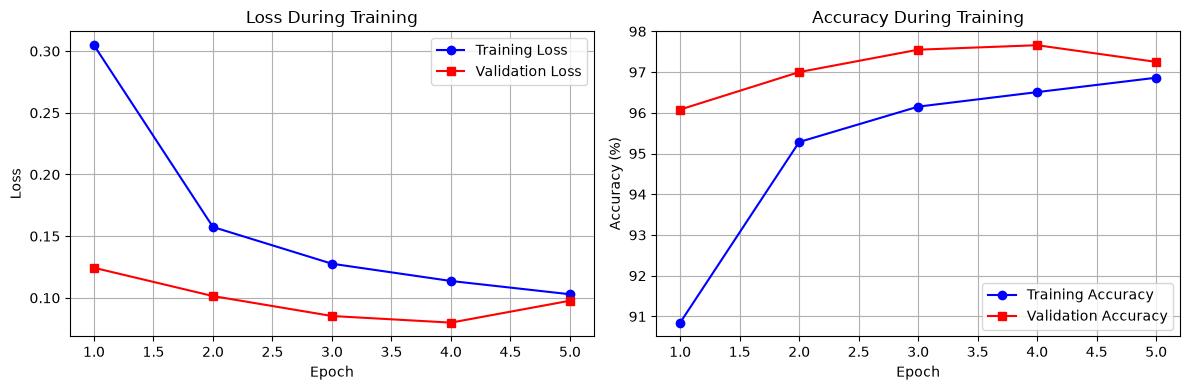

Final test accuracy: 97.25%


In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss curves
ax1.plot(range(1, epochs+1), train_losses, 'b-', label='Training Loss', marker='o')
ax1.plot(range(1, epochs+1), test_losses, 'r-', label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss During Training')
ax1.legend()
ax1.grid(True)

# Plot accuracy curves
# Plot the accuracy curves
# Hint: Similar to loss curves but for accuracies
ax2.plot(range(1, epochs+1), train_accuracies, 'b-', label='Training Accuracy', marker='o')
ax2.plot(range(1, epochs+1), test_accuracies, 'r-', label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy During Training')
ax2.legend()
ax2.grid(True)


plt.tight_layout()
plt.show()

print(f"Final test accuracy: {test_accuracies[-1]:.2f}%")

### 1.7 Visualize Predictions

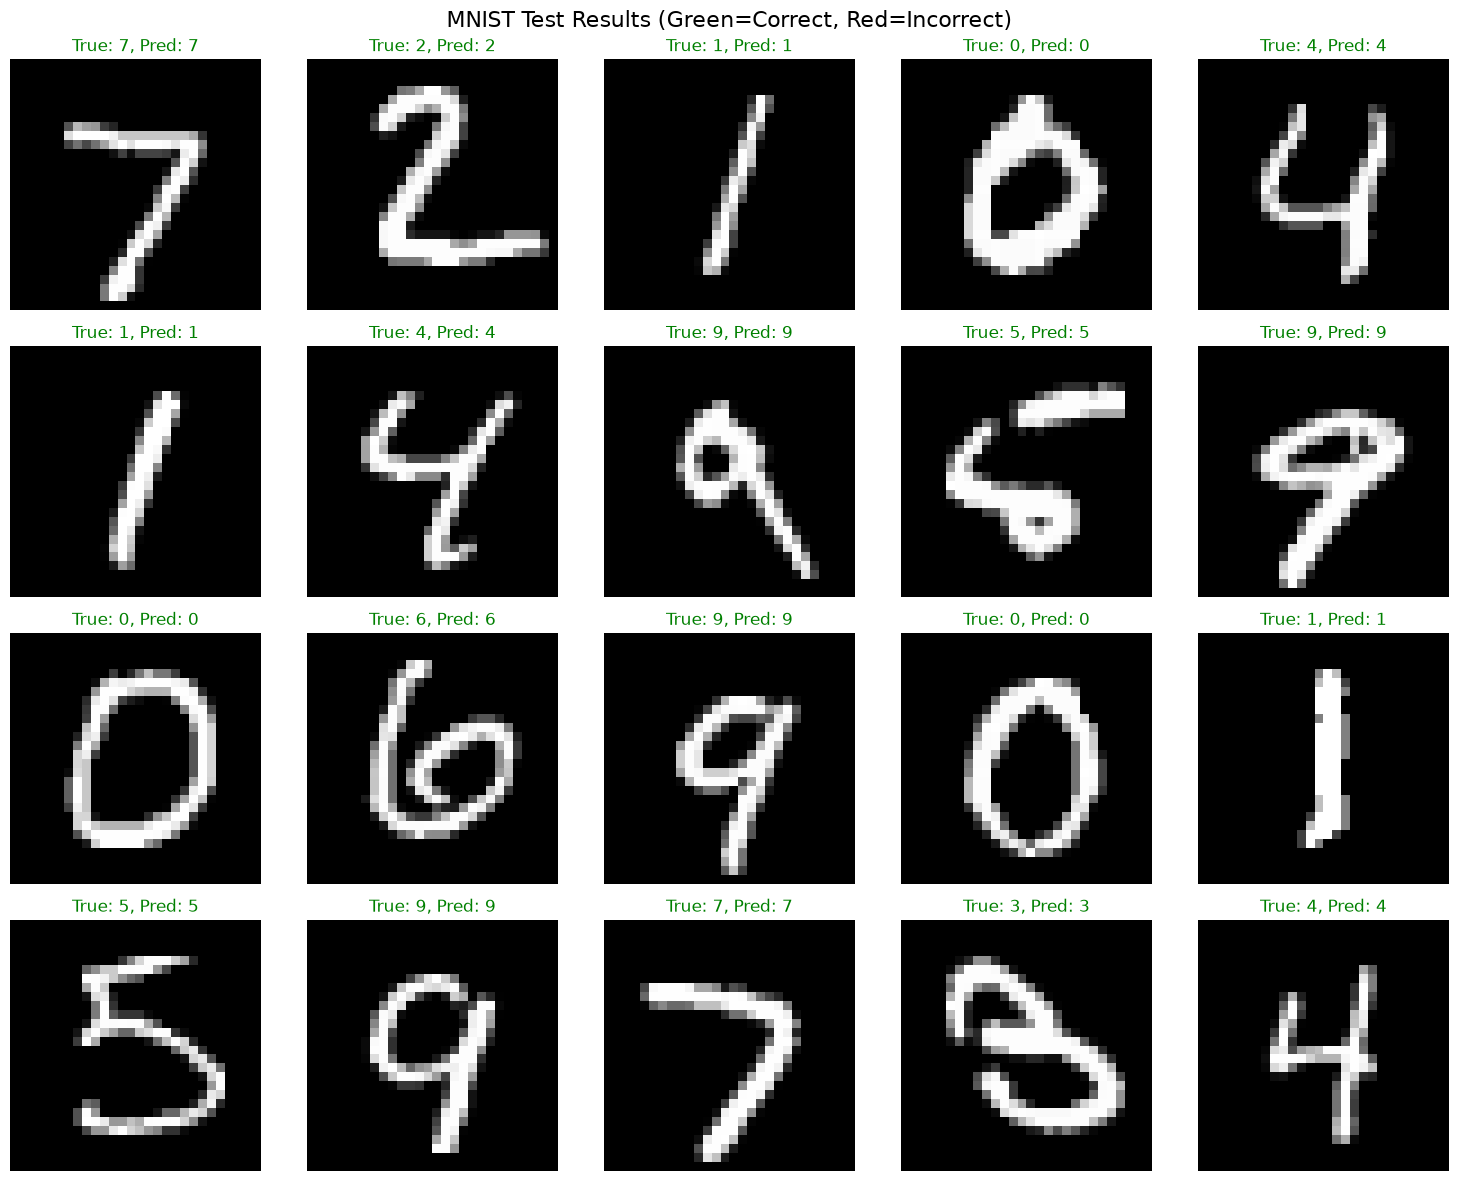

Accuracy for displayed samples: 100.0% (20/20)


In [84]:
def visualize_predictions(model, test_loader, num_samples=20):
    model.eval()
    
    # Get one batch of data
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    
    # Move data to device and get predictions
    # Hint: Move images to device, get outputs, then move back to CPU for visualization
    images_gpu = images.to(device)
    with torch.no_grad():
        outputs = model(images_gpu)
        _, predictions = torch.max(outputs, 1)
    
    # Move back to CPU for visualization
    images = images.cpu()
    predictions = predictions.cpu()
  
    
    # Visualize the prediction results
    # Hint: Create subplots and show images with true vs predicted labels
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.ravel()
    
    for i in range(num_samples):
        img = images[i].squeeze()
        true_label = labels[i].item()
        pred_label = predictions[i].item()
        
        axes[i].imshow(img, cmap='gray')
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}, Pred: {pred_label}', color=color)
        axes[i].axis('off')
    
    plt.suptitle('MNIST Test Results (Green=Correct, Red=Incorrect)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Calculate accuracy for displayed samples
    correct = (predictions[:num_samples] == labels[:num_samples]).sum().item()
    accuracy = correct / num_samples * 100
    print(f"Accuracy for displayed samples: {accuracy:.1f}% ({correct}/{num_samples})")

# Visualize prediction results
visualize_predictions(model, test_loader)

img/init/1.jpg: predicted digit = 5
img/init/2.jpg: predicted digit = 7
img/init/4.jpg: predicted digit = 4
img/init/5.jpg: predicted digit = 9
img/init/6.jpg: predicted digit = 3
img/init/7.jpg: predicted digit = 6
img/8.jpg: predicted digit = 8


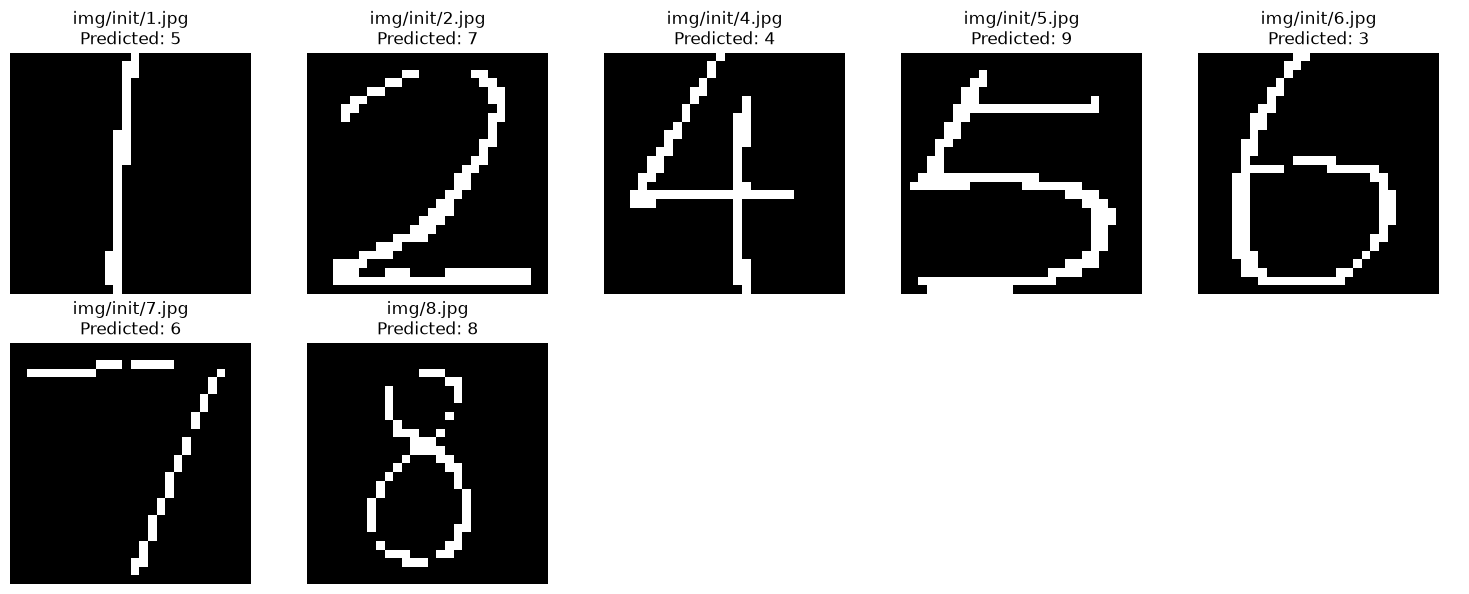

In [85]:
# Predict custom handwritten digit images with the trained MLP
from PIL import Image

image_paths = [
    'img/init/1.jpg',
    'img/init/2.jpg',
    'img/init/4.jpg',
    'img/init/5.jpg',
    'img/init/6.jpg',
    'img/init/7.jpg',
    'img/8.jpg',
    # Replace with one or more image paths
]

def predict_custom_mnist_images(model, image_paths):
    if not image_paths:
        raise ValueError('image_paths cannot be empty.')

    def binarize_tensor(x, threshold=0.5):
        return (x > threshold).float()

    model.eval()
    display_transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: 1.0 - x),
        transforms.Lambda(binarize_tensor),
    ])
    model_transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: 1.0 - x),
        transforms.Lambda(binarize_tensor),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])

    display_images = []
    model_images = []
    valid_paths = []

    for image_path in image_paths:
        try:
            image = Image.open(image_path).convert('L')
        except (FileNotFoundError, OSError) as error:
            raise FileNotFoundError(f'Cannot open image: {image_path}') from error

        display_images.append(display_transform(image))
        model_images.append(model_transform(image))
        valid_paths.append(image_path)

    batch = torch.stack(model_images).to(device)
    with torch.no_grad():
        predictions = model(batch).argmax(dim=1).cpu().tolist()

    columns = min(5, len(valid_paths))
    rows = (len(valid_paths) + columns - 1) // columns
    fig, axes = plt.subplots(
        rows, columns, figsize=(3 * columns, 3 * rows), squeeze=False
    )
    axes = axes.ravel()

    for index, (path, image, prediction) in enumerate(
        zip(valid_paths, display_images, predictions)
    ):
        axes[index].imshow(image.squeeze(0), cmap='gray', vmin=0, vmax=1)
        axes[index].set_title(f'{path}\nPredicted: {prediction}')
        axes[index].axis('off')
        print(f'{path}: predicted digit = {prediction}')

    for axes_index in range(len(valid_paths), len(axes)):
        axes[axes_index].axis('off')

    plt.tight_layout()
    plt.show()

predict_custom_mnist_images(model, image_paths)


While MLPs perform well on tabular data, they have been largely replaced by CNNs in image processing tasks due to their large parameter count and inability to effectively capture spatial features. We will learn CNNs in Task2.

---

## Task 2: BloodMNIST Classification with CNN

**BloodMNIST** is a biomedical microscopy dataset from the MedMNIST collection. It contains **17,092 RGB images** of individual normal blood cells grouped into **8 classes**. The official split contains 11,959 training images, 1,712 validation images, and 3,421 test images. Source images were center-cropped and resized to 28 × 28 pixels for a lightweight multi-class classification benchmark.

This task replaces everyday-object classification with a chemically and biologically relevant problem: learning cell morphology from stained blood-smear images. A CNN can learn local patterns such as cell boundaries, nuclear shape, granularity, and color distribution.

> **Important:** This notebook is an educational image-classification exercise, not a clinical diagnostic system.

References: [MedMNIST](https://medmnist.com/) · [MedMNIST API](https://github.com/MedMNIST/MedMNIST) · [BloodMNIST CNN project](https://github.com/Nilsvanesostos/BloodMNIST)


### 2.1 Imports

In [86]:
import sys
import subprocess

try:
    import medmnist
except ModuleNotFoundError:
    print(
        "MedMNIST is not installed. "
        "Installing it in the current notebook environment..."
    )
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "medmnist"
    ])
    import medmnist

from medmnist import INFO
print(f"MedMNIST version: {medmnist.__version__}")

import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix


# Automatic device detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

torch.manual_seed(42)
np.random.seed(42)


MedMNIST version: 3.0.2
Using device: cpu


### 2.2 Load Data

The MedMNIST API downloads the official dataset and preserves its predefined training, validation, and test splits. BloodMNIST images are RGB, so each tensor has shape **3 × 28 × 28**.

We normalize every channel from the range [0, 1] to approximately [−1, 1]. The test set is kept untouched until the final evaluation.

In [87]:
# Dataset metadata
data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

class_names = [info['label'][str(i)] for i in range(len(info['label']))]
# Use a shorter display name for plots and prediction titles
class_names[3] = 'granulocytes'
n_channels = info['n_channels']
n_classes = len(class_names)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * n_channels, std=[0.5] * n_channels),
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * n_channels, std=[0.5] * n_channels),
])

# Store the downloaded dataset inside this project's data folder
data_root = './data'


from pathlib import Path

# Choose the location where bloodmnist.npz was uploaded
data_file = Path("./data/bloodmnist.npz").resolve()

if not data_file.exists():
    raise FileNotFoundError(
        f"BloodMNIST dataset was not found: {data_file}"
    )

print(f"Using uploaded dataset: {data_file}")

data_root = str(data_file.parent)

train_dataset = DataClass(split="train", root=data_root,transform=transform_train, download=False)
val_dataset = DataClass(split="val", root=data_root, transform=transform_eval,download=False)
test_dataset = DataClass(split="test", root=data_root, transform=transform_eval, download=False)

print("BloodMNIST has been loaded successfully.")

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Task: {info['task']}")
print(f"Channels: {n_channels}; classes: {n_classes}")
print(f"Train/validation/test: {len(train_dataset):,} / {len(val_dataset):,} / {len(test_dataset):,}")


Using uploaded dataset: E:\G2.2\aichem\p5\data\bloodmnist.npz
BloodMNIST has been loaded successfully.
Task: multi-class
Channels: 3; classes: 8
Train/validation/test: 11,959 / 1,712 / 3,421


In [88]:
print("BloodMNIST classes:")
for index, name in enumerate(class_names):
    print(f"  {index}: {name}")

image, label = train_dataset[0]
print(f"One image tensor shape: {image.shape}")
print(f"One label shape: {np.asarray(label).shape}; value: {int(np.asarray(label).squeeze())}")


BloodMNIST classes:
  0: basophil
  1: eosinophil
  2: erythroblast
  3: granulocytes
  4: lymphocyte
  5: monocyte
  6: neutrophil
  7: platelet
One image tensor shape: torch.Size([3, 28, 28])
One label shape: (1,); value: 7


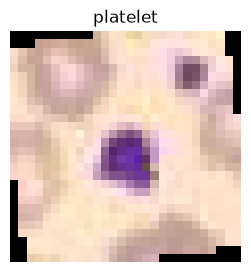

In [89]:
# Undo normalization for display
def denormalize_blood_image(tensor):
    return torch.clamp(tensor * 0.5 + 0.5, 0, 1)

image_show = denormalize_blood_image(image)
plt.figure(figsize=(3, 3))
plt.imshow(image_show.permute(1, 2, 0))
plt.title(class_names[int(np.asarray(label).squeeze())])
plt.axis('off')
plt.show()


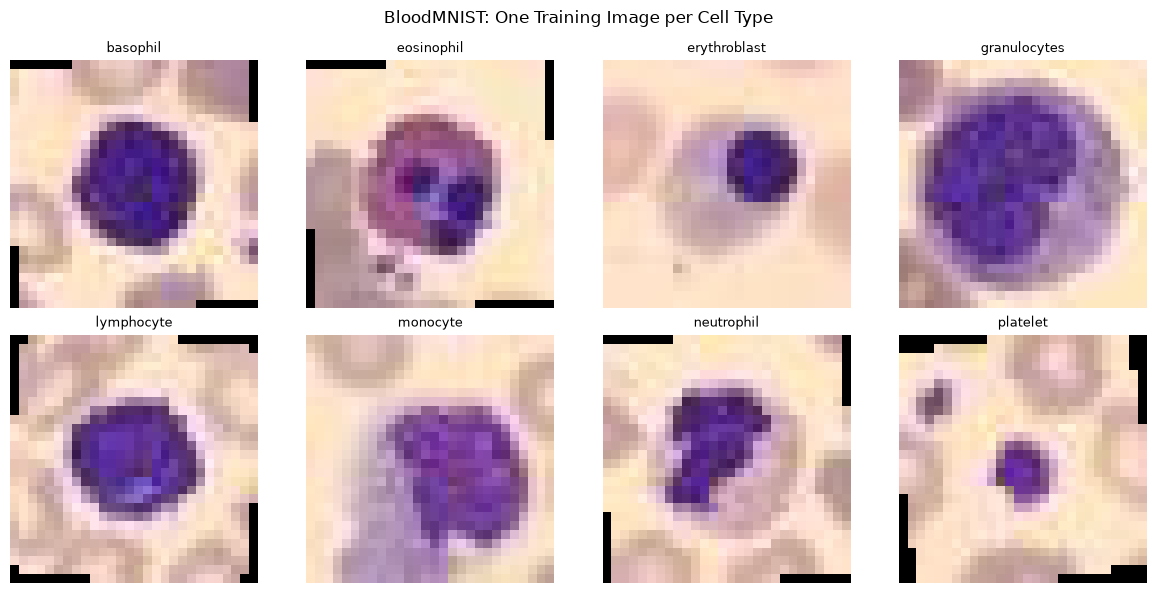

In [90]:
# Visualize one BloodMNIST sample from each class
# Hint: Search the training set until all 8 labels have been found.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
found = set()

for image, label in train_dataset:
    class_id = int(np.asarray(label).squeeze())
    if class_id not in found:
        ax = axes.ravel()[class_id]
        ax.imshow(denormalize_blood_image(image).permute(1, 2, 0))
        ax.set_title(class_names[class_id], fontsize=9)
        ax.axis('off')
        found.add(class_id)
    if len(found) == n_classes:
        break

plt.suptitle('BloodMNIST: One Training Image per Cell Type')
plt.tight_layout()
plt.show()



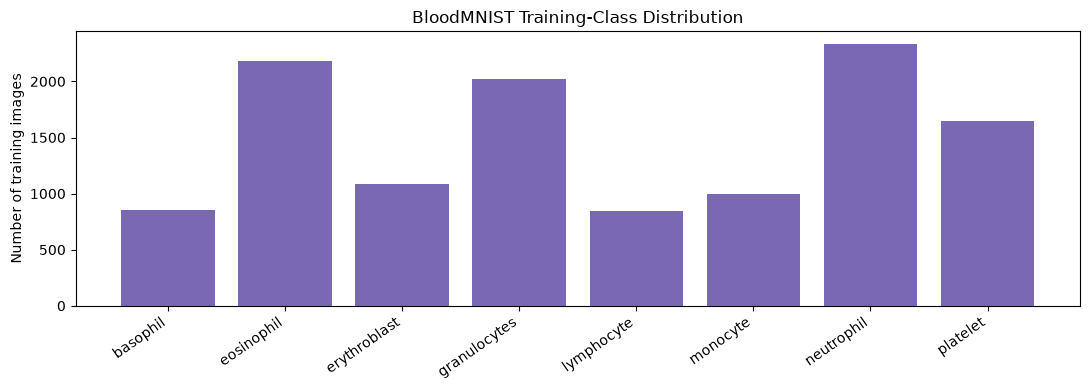

basophil                                                  852
eosinophil                                               2181
erythroblast                                             1085
granulocytes                                             2026
lymphocyte                                                849
monocyte                                                  993
neutrophil                                               2330
platelet                                                 1643


In [91]:
# Inspect class balance in the training split
train_labels = np.asarray(train_dataset.labels).squeeze().astype(int)
class_counts = np.bincount(train_labels, minlength=n_classes)

plt.figure(figsize=(11, 4))
plt.bar(range(n_classes), class_counts, color='#7b68b5')
plt.xticks(range(n_classes), class_names, rotation=35, ha='right')
plt.ylabel('Number of training images')
plt.title('BloodMNIST Training-Class Distribution')
plt.tight_layout()
plt.show()

for name, count in zip(class_names, class_counts):
    print(f"{name:55s} {count:5d}")


### 2.3 Define CNN Model

A **Convolutional Neural Network (CNN)** learns local visual patterns by sliding trainable kernels across an image. Early layers often respond to edges and color transitions; deeper layers combine these signals into morphology-related features.

<img src="./img/CNN.png" alt="CNN architecture" style="width: 800px"/> </br>
**Figure 2.** A typical CNN architecture for image recognition.

**TODO:** Design the following CNN model for BloodMNIST:

- **Input layer:** 3 × 28 × 28 RGB image
- **Output layer:** 8 logits, one for each blood-cell class
- **Convolutional layers:** learn local color, texture, boundary, and nuclear patterns
- **Pooling layers:** reduce spatial size and computation
- **Fully connected layer:** converts learned features into class scores

Examine how the channel count changes from 3 → 32 → 64 → 128. Why does the spatial size decrease while the number of feature maps increases?
You could also define your own model.

In [92]:

class BloodCellCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        # TODO: Define convolutional layers
        self.features = nn.Sequential(
            nn.Conv2d( 3, 32, kernel_size= 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                      

            nn.Conv2d( 32, 64, kernel_size= 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                     

            nn.Conv2d( 64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((3, 3)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )
   # TODO end
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = BloodCellCNN(num_classes=n_classes)
print("Blood-cell CNN structure:")
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Blood-cell CNN structure:
BloodCellCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(3, 3))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=F

In [93]:
# Check the tensor shapes before training
sample_images, sample_labels = next(iter(train_loader))
with torch.no_grad():
    sample_logits = model(sample_images)

print(f"Input batch:  {sample_images.shape}")
print(f"Labels:       {sample_labels.shape}")
print(f"Output logits:{sample_logits.shape}")
assert sample_logits.shape == (sample_images.size(0), n_classes)


Input batch:  torch.Size([64, 3, 28, 28])
Labels:       torch.Size([64, 1])
Output logits:torch.Size([64, 8])


### 2.4 Define Training and Evaluation Functions

`CrossEntropyLoss` is appropriate because BloodMNIST is a single-label, eight-class classification task. MedMNIST stores labels with shape `(batch, 1)`, so the functions flatten them to `(batch,)` before calculating the loss.

In [94]:
def run_epoch(model, loader, criterion, optimizer=None, description='Training'):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, correct, total = 0.0, 0, 0

    progress = tqdm(loader, desc=description, leave=False)
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for images, labels in progress:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)

            if is_training:
                optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            progress.set_postfix(loss=f'{loss.item():.4f}', acc=f'{100 * correct / total:.2f}%')

    return total_loss / total, 100 * correct / total


### 2.5 Train the Model

The validation split guides model selection; it is not merged with the test set. The best validation checkpoint is restored before the final test evaluation.

In [95]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

epochs = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_accuracy = -1.0
best_state = None

print(f"Starting BloodMNIST CNN training on {device}...")
start_time = time.time()

for epoch in tqdm(range(epochs), desc='CNN Training Progress'):
    train_loss, train_acc = run_epoch(
        model, train_loader, criterion, optimizer,
        description=f'Epoch {epoch + 1} [Training]'
    )
    val_loss, val_acc = run_epoch(
        model, val_loader, criterion,
        description=f'Epoch {epoch + 1} [Validation]'
    )
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_state = {name: tensor.detach().cpu().clone()
                      for name, tensor in model.state_dict().items()}

    print(f"Epoch [{epoch + 1}/{epochs}] | "
          f"train loss {train_loss:.4f}, acc {train_acc:.2f}% | "
          f"val loss {val_loss:.4f}, acc {val_acc:.2f}%")

print(f"Training time: {time.time() - start_time:.1f} s")
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

model.load_state_dict(best_state)
test_loss, test_accuracy = run_epoch(model, test_loader, criterion, description='Final Test')
print(f"Final held-out test loss: {test_loss:.4f}")
print(f"Final held-out test accuracy: {test_accuracy:.2f}%")


Starting BloodMNIST CNN training on cpu...


CNN Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 1 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [1/10] | train loss 0.6829, acc 74.77% | val loss 0.4590, acc 82.71%


Epoch 2 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 2 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [2/10] | train loss 0.4107, acc 85.07% | val loss 0.3707, acc 85.86%


Epoch 3 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 3 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [3/10] | train loss 0.3501, acc 87.46% | val loss 0.3827, acc 86.10%


Epoch 4 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 4 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [4/10] | train loss 0.3086, acc 88.96% | val loss 0.3386, acc 87.09%


Epoch 5 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 5 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [5/10] | train loss 0.2706, acc 90.22% | val loss 0.2385, acc 92.46%


Epoch 6 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 6 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [6/10] | train loss 0.2481, acc 90.89% | val loss 0.1733, acc 93.81%


Epoch 7 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 7 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [7/10] | train loss 0.2233, acc 92.01% | val loss 0.1732, acc 93.93%


Epoch 8 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 8 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [8/10] | train loss 0.2021, acc 93.07% | val loss 0.1548, acc 94.98%


Epoch 9 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 9 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [9/10] | train loss 0.1832, acc 93.41% | val loss 0.1466, acc 94.98%


Epoch 10 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 10 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [10/10] | train loss 0.1783, acc 93.88% | val loss 0.1396, acc 95.21%
Training time: 261.0 s
Best validation accuracy: 95.21%


Final Test:   0%|          | 0/54 [00:00<?, ?it/s]

Final held-out test loss: 0.1582
Final held-out test accuracy: 94.45%


### 2.6 Visualize Training Results

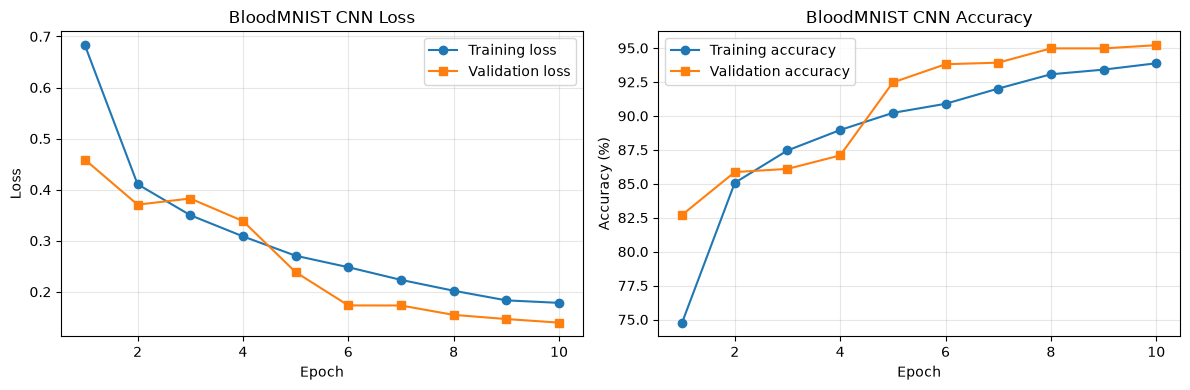

In [96]:
epoch_axis = range(1, epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epoch_axis, train_losses, 'o-', label='Training loss')
ax1.plot(epoch_axis, val_losses, 's-', label='Validation loss')
ax1.set(xlabel='Epoch', ylabel='Loss', title='BloodMNIST CNN Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(epoch_axis, train_accuracies, 'o-', label='Training accuracy')
ax2.plot(epoch_axis, val_accuracies, 's-', label='Validation accuracy')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='BloodMNIST CNN Accuracy')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


### 2.7 Visualize Predictions and Errors

Green titles indicate correct predictions and red titles indicate errors. Error analysis is especially important when classes have similar morphology or unequal sample counts.

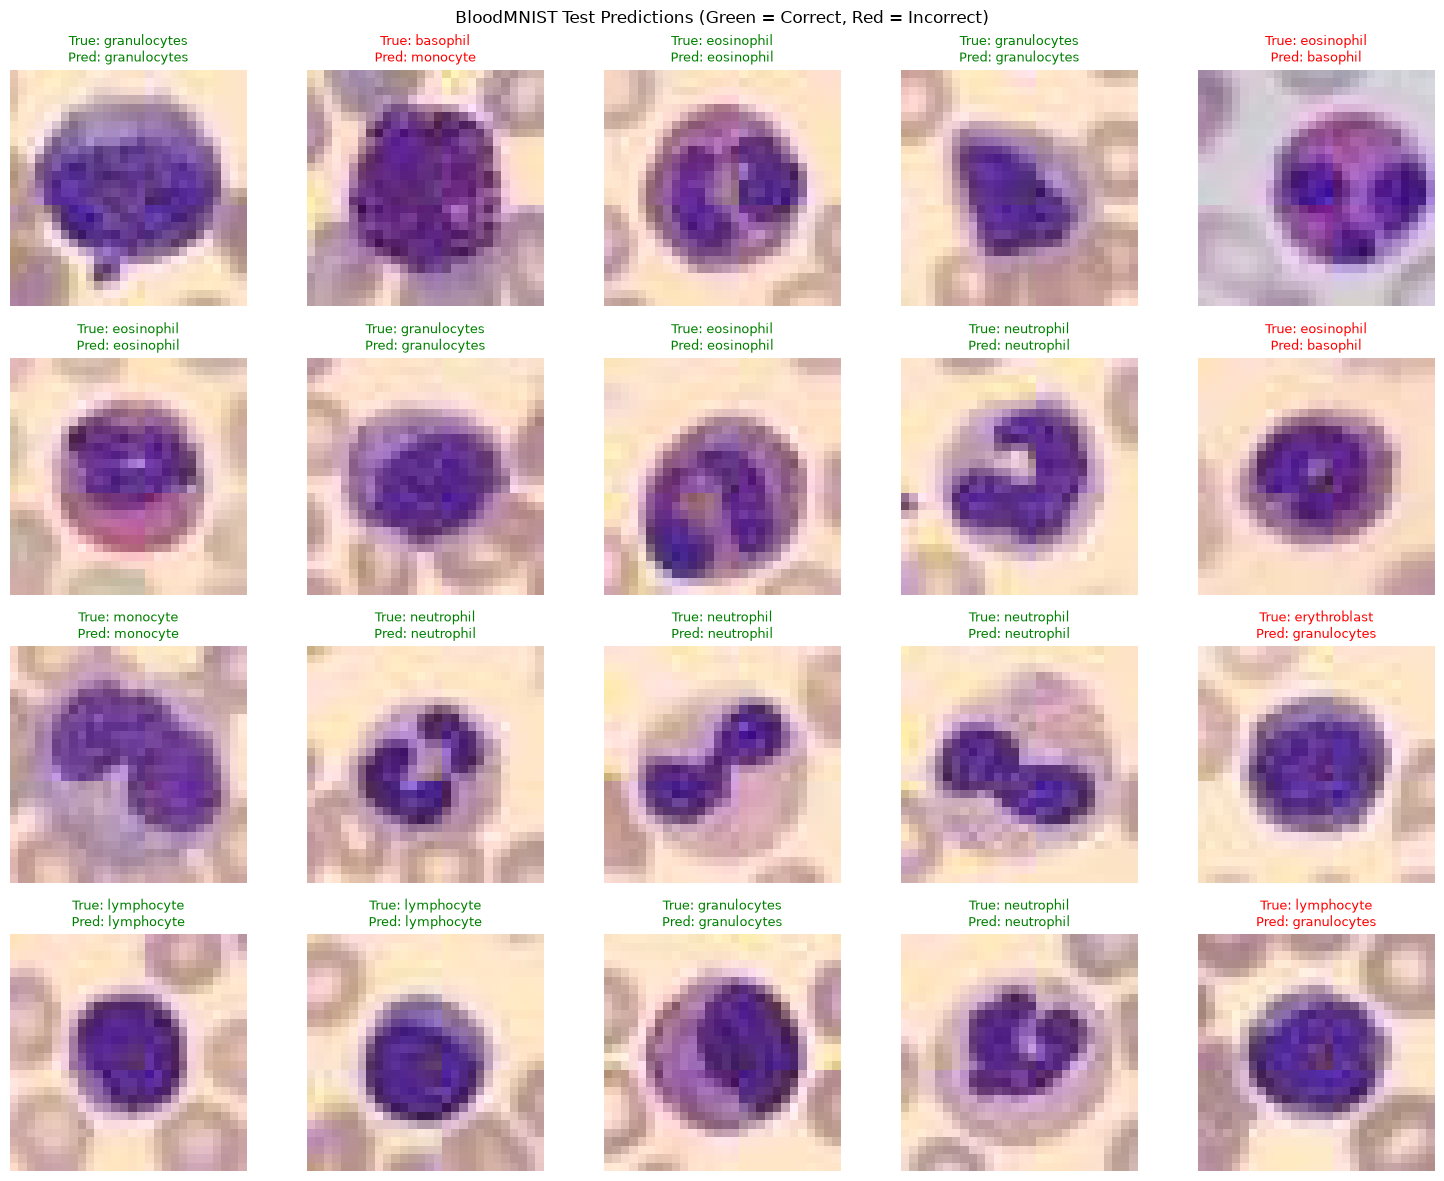

In [97]:
def collect_predictions(model, loader):
    model.eval()
    all_images, all_labels, all_predictions = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            predictions = logits.argmax(dim=1).cpu()
            all_images.append(images.cpu())
            all_labels.append(labels.squeeze(1).long().cpu())
            all_predictions.append(predictions)
    return (torch.cat(all_images), torch.cat(all_labels), torch.cat(all_predictions))

test_images, test_labels, test_predictions = collect_predictions(model, test_loader)

num_samples = 20
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for i, ax in enumerate(axes.ravel()):
    image = denormalize_blood_image(test_images[i])
    truth = test_labels[i].item()
    prediction = test_predictions[i].item()
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"True: {class_names[truth]}\nPred: {class_names[prediction]}",
                 color='green' if truth == prediction else 'red', fontsize=9)
    ax.axis('off')

plt.suptitle('BloodMNIST Test Predictions (Green = Correct, Red = Incorrect)')
plt.tight_layout()
plt.show()


In [98]:
# Classification report and confusion matrix
blood_y_test = test_labels.numpy()
blood_y_pred = test_predictions.numpy()

print("Classification Report:")
print(classification_report(
    blood_y_test,
    blood_y_pred,
    labels=range(n_classes),
    target_names=class_names,
    digits=4,
    zero_division=0
))

blood_conf_mat = confusion_matrix(
    blood_y_test,
    blood_y_pred,
    labels=range(n_classes)
)
print("Confusion Matrix:")
print(blood_conf_mat)

# Accuracy for each cell type = correct predictions / samples of that type
class_totals = blood_conf_mat.sum(axis=1)
class_correct = np.diag(blood_conf_mat)
class_accuracies = np.divide(
    class_correct, class_totals,
    out=np.zeros_like(class_correct, dtype=float),
    where=class_totals != 0
)

print("\nAccuracy for Each Cell Type:")
for name, accuracy, correct, total in zip(
    class_names, class_accuracies, class_correct, class_totals
):
    print(f"{name:15s}: {accuracy * 100:6.2f}% ({correct}/{total})")

# Preserve the original row-normalized confusion-matrix heat map
confusion = torch.zeros(n_classes, n_classes, dtype=torch.int64)
for truth, prediction in zip(test_labels, test_predictions):
    confusion[truth, prediction] += 1

row_totals = confusion.sum(dim=1, keepdim=True).clamp_min(1)
confusion_percent = confusion.float() / row_totals * 100


Classification Report:
              precision    recall  f1-score   support

    basophil     0.8876    0.9057    0.8966       244
  eosinophil     0.9919    0.9872    0.9896       624
erythroblast     0.9801    0.9486    0.9641       311
granulocytes     0.8531    0.8929    0.8726       579
  lymphocyte     0.9280    0.9547    0.9412       243
    monocyte     0.9249    0.8239    0.8715       284
  neutrophil     0.9627    0.9700    0.9663       666
    platelet     1.0000    1.0000    1.0000       470

    accuracy                         0.9445      3421
   macro avg     0.9410    0.9354    0.9377      3421
weighted avg     0.9452    0.9445    0.9445      3421

Confusion Matrix:
[[221   0   0  13   3   6   1   0]
 [  3 616   0   1   1   1   2   0]
 [  2   0 295   7   2   1   4   0]
 [ 18   4   3 517   8  11  18   0]
 [  2   0   1   8 232   0   0   0]
 [  3   0   1  42   4 234   0   0]
 [  0   1   1  18   0   0 646   0]
 [  0   0   0   0   0   0   0 470]]

Accuracy for Each Cell Typ

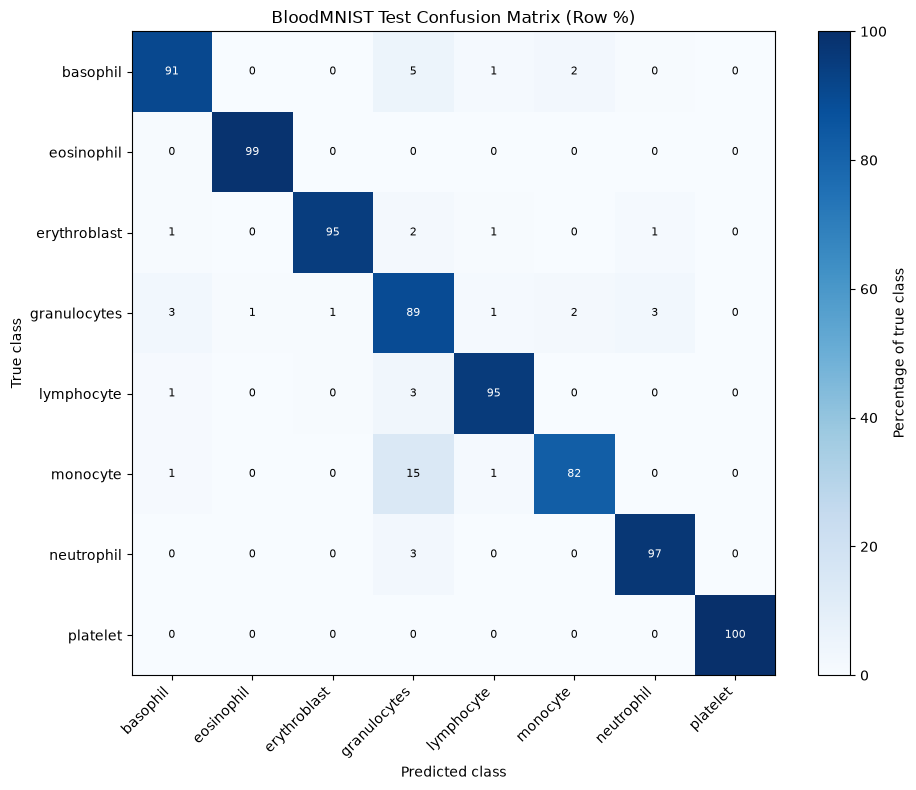

In [99]:

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(confusion_percent.numpy(), cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(n_classes), class_names, rotation=45, ha='right')
ax.set_yticks(range(n_classes), class_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('BloodMNIST Test Confusion Matrix (Row %)')

for row in range(n_classes):
    for column in range(n_classes):
        value = confusion_percent[row, column].item()
        ax.text(column, row, f'{value:.0f}', ha='center', va='center',
                color='white' if value > 50 else 'black', fontsize=8)

fig.colorbar(image, ax=ax, label='Percentage of true class')
plt.tight_layout()
plt.show()

### 2.8 将损失函数由交叉熵损失改成均方误差损失，绘制loss-epoch，accuracy-epoch图

MSE epoch 1 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 1 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [1/10] | train loss 0.0432, acc 74.14% | val loss 0.0245, acc 86.97%


MSE epoch 2 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 2 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [2/10] | train loss 0.0272, acc 84.61% | val loss 0.0215, acc 87.56%


MSE epoch 3 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 3 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [3/10] | train loss 0.0229, acc 87.37% | val loss 0.0215, acc 87.62%


MSE epoch 4 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 4 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [4/10] | train loss 0.0204, acc 88.55% | val loss 0.0164, acc 91.06%


MSE epoch 5 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 5 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [5/10] | train loss 0.0181, acc 90.12% | val loss 0.0158, acc 91.65%


MSE epoch 6 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 6 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [6/10] | train loss 0.0170, acc 90.72% | val loss 0.0138, acc 92.35%


MSE epoch 7 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 7 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [7/10] | train loss 0.0149, acc 92.05% | val loss 0.0140, acc 92.11%


MSE epoch 8 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 8 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [8/10] | train loss 0.0139, acc 92.66% | val loss 0.0106, acc 94.39%


MSE epoch 9 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 9 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [9/10] | train loss 0.0131, acc 93.07% | val loss 0.0100, acc 94.80%


MSE epoch 10 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

MSE epoch 10 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

MSE epoch [10/10] | train loss 0.0123, acc 93.49% | val loss 0.0095, acc 94.68%


MSE final test:   0%|          | 0/54 [00:00<?, ?it/s]

MSE test accuracy: 93.42%


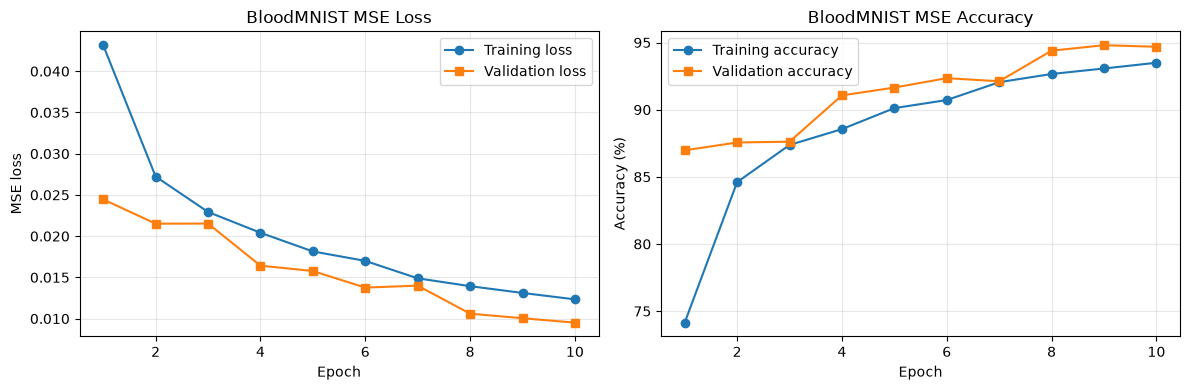

In [100]:
# 2.8: Train BloodMNIST CNN with mean squared error loss
mse_model = BloodCellCNN(num_classes=n_classes).to(device)
mse_criterion = nn.MSELoss()
mse_optimizer = optim.AdamW(mse_model.parameters(), lr=0.001, weight_decay=1e-4)
mse_epochs = 10
mse_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    mse_optimizer, T_max=mse_epochs
)

def run_mse_epoch(model, loader, criterion, optimizer=None, description='MSE'):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, correct, total = 0.0, 0, 0

    progress = tqdm(loader, desc=description, leave=False)
    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, labels in progress:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)
            targets = torch.nn.functional.one_hot(
                labels, num_classes=n_classes
            ).float()

            if is_training:
                optimizer.zero_grad()

            probabilities = torch.softmax(model(images), dim=1)
            loss = criterion(probabilities, targets)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            predictions = probabilities.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100 * correct / total

mse_train_losses, mse_val_losses = [], []
mse_train_accuracies, mse_val_accuracies = [], []
mse_best_state, mse_best_val_accuracy = None, -1.0

for epoch in range(mse_epochs):
    train_loss, train_acc = run_mse_epoch(
        mse_model, train_loader, mse_criterion, mse_optimizer,
        description=f'MSE epoch {epoch + 1} [Training]'
    )
    val_loss, val_acc = run_mse_epoch(
        mse_model, val_loader, mse_criterion,
        description=f'MSE epoch {epoch + 1} [Validation]'
    )
    mse_scheduler.step()

    mse_train_losses.append(train_loss)
    mse_val_losses.append(val_loss)
    mse_train_accuracies.append(train_acc)
    mse_val_accuracies.append(val_acc)
    if val_acc > mse_best_val_accuracy:
        mse_best_val_accuracy = val_acc
        mse_best_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in mse_model.state_dict().items()
        }
    print(
        f'MSE epoch [{epoch + 1}/{mse_epochs}] | '
        f'train loss {train_loss:.4f}, acc {train_acc:.2f}% | '
        f'val loss {val_loss:.4f}, acc {val_acc:.2f}%'
    )

mse_model.load_state_dict(mse_best_state)
mse_test_loss, mse_test_accuracy = run_mse_epoch(
    mse_model, test_loader, mse_criterion, description='MSE final test'
)
print(f'MSE test accuracy: {mse_test_accuracy:.2f}%')

mse_epoch_axis = range(1, mse_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(mse_epoch_axis, mse_train_losses, 'o-', label='Training loss')
ax1.plot(mse_epoch_axis, mse_val_losses, 's-', label='Validation loss')
ax1.set(xlabel='Epoch', ylabel='MSE loss', title='BloodMNIST MSE Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax2.plot(mse_epoch_axis, mse_train_accuracies, 'o-', label='Training accuracy')
ax2.plot(mse_epoch_axis, mse_val_accuracies, 's-', label='Validation accuracy')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='BloodMNIST MSE Accuracy')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

### 2.9 将relu替换为sigmoid，绘制loss-epoch，accuracy-epoch图

Sigmoid epoch 1 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 1 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [1/10] | train loss 1.2225, acc 57.04% | val loss 2.1352, acc 29.44%


Sigmoid epoch 2 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 2 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [2/10] | train loss 0.7727, acc 71.13% | val loss 0.7474, acc 71.09%


Sigmoid epoch 3 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 3 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [3/10] | train loss 0.6396, acc 76.61% | val loss 1.2081, acc 55.32%


Sigmoid epoch 4 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 4 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [4/10] | train loss 0.5530, acc 79.53% | val loss 1.0074, acc 59.29%


Sigmoid epoch 5 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 5 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [5/10] | train loss 0.5018, acc 81.19% | val loss 0.9542, acc 64.31%


Sigmoid epoch 6 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 6 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [6/10] | train loss 0.4741, acc 82.38% | val loss 1.1718, acc 58.70%


Sigmoid epoch 7 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 7 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [7/10] | train loss 0.4393, acc 84.12% | val loss 0.6884, acc 75.23%


Sigmoid epoch 8 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 8 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [8/10] | train loss 0.4182, acc 85.16% | val loss 0.4655, acc 81.48%


Sigmoid epoch 9 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 9 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [9/10] | train loss 0.4035, acc 85.93% | val loss 0.4986, acc 80.96%


Sigmoid epoch 10 [Training]:   0%|          | 0/187 [00:00<?, ?it/s]

Sigmoid epoch 10 [Validation]:   0%|          | 0/27 [00:00<?, ?it/s]

Sigmoid epoch [10/10] | train loss 0.3922, acc 85.92% | val loss 0.3324, acc 88.32%


Sigmoid final test:   0%|          | 0/54 [00:00<?, ?it/s]

Sigmoid test accuracy: 86.82%


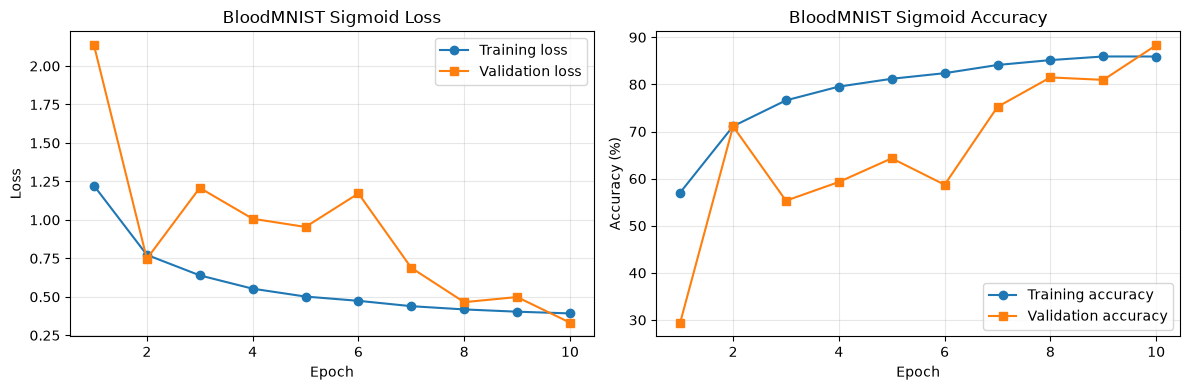

In [101]:
# 2.9: Train BloodMNIST CNN with Sigmoid hidden activations
class BloodCellSigmoidCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.Sigmoid(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.Sigmoid(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.Sigmoid(),
            nn.AdaptiveAvgPool2d((3, 3)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128 * 3 * 3, 128),
            nn.Sigmoid(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

sigmoid_model = BloodCellSigmoidCNN(num_classes=n_classes).to(device)
sigmoid_criterion = nn.CrossEntropyLoss()
sigmoid_optimizer = optim.AdamW(
    sigmoid_model.parameters(), lr=0.001, weight_decay=1e-4
)
sigmoid_epochs = 10
sigmoid_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    sigmoid_optimizer, T_max=sigmoid_epochs
)
sigmoid_train_losses, sigmoid_val_losses = [], []
sigmoid_train_accuracies, sigmoid_val_accuracies = [], []
sigmoid_best_state, sigmoid_best_val_accuracy = None, -1.0

for epoch in range(sigmoid_epochs):
    train_loss, train_acc = run_epoch(
        sigmoid_model, train_loader, sigmoid_criterion, sigmoid_optimizer,
        description=f'Sigmoid epoch {epoch + 1} [Training]'
    )
    val_loss, val_acc = run_epoch(
        sigmoid_model, val_loader, sigmoid_criterion,
        description=f'Sigmoid epoch {epoch + 1} [Validation]'
    )
    sigmoid_scheduler.step()
    sigmoid_train_losses.append(train_loss)
    sigmoid_val_losses.append(val_loss)
    sigmoid_train_accuracies.append(train_acc)
    sigmoid_val_accuracies.append(val_acc)
    if val_acc > sigmoid_best_val_accuracy:
        sigmoid_best_val_accuracy = val_acc
        sigmoid_best_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in sigmoid_model.state_dict().items()
        }
    print(
        f'Sigmoid epoch [{epoch + 1}/{sigmoid_epochs}] | '
        f'train loss {train_loss:.4f}, acc {train_acc:.2f}% | '
        f'val loss {val_loss:.4f}, acc {val_acc:.2f}%'
    )

sigmoid_model.load_state_dict(sigmoid_best_state)
sigmoid_test_loss, sigmoid_test_accuracy = run_epoch(
    sigmoid_model, test_loader, sigmoid_criterion,
    description='Sigmoid final test'
)
print(f'Sigmoid test accuracy: {sigmoid_test_accuracy:.2f}%')

sigmoid_epoch_axis = range(1, sigmoid_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(sigmoid_epoch_axis, sigmoid_train_losses, 'o-', label='Training loss')
ax1.plot(sigmoid_epoch_axis, sigmoid_val_losses, 's-', label='Validation loss')
ax1.set(xlabel='Epoch', ylabel='Loss', title='BloodMNIST Sigmoid Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax2.plot(sigmoid_epoch_axis, sigmoid_train_accuracies, 'o-', label='Training accuracy')
ax2.plot(sigmoid_epoch_axis, sigmoid_val_accuracies, 's-', label='Validation accuracy')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='BloodMNIST Sigmoid Accuracy')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

## Task 3: Compare CPU and GPU Performance

Choose one task from task 1 or 2 and run again on GPU on another notebook. Record the total training time.
- Plot the time needed for CPU and GPU configurations. </br>
- Plot a total cost vs machine configuration bar chart. (optional)

Recomended comparison: 
| Machine Type       | CPU      | CPU       | GPU          | GPU                     |
|--------------------|----------|-----------|--------------|-------------------------|
| Machine Configuration | c2m4     | c4m16     |c3m4* NVIDIA T4    | c8_m32_1 * NVIDIA V100 <br> (optional) |
| Cost (¥/h)         | 0.3        | 0.6    | 7         | 11                      |

### 3.1 task1

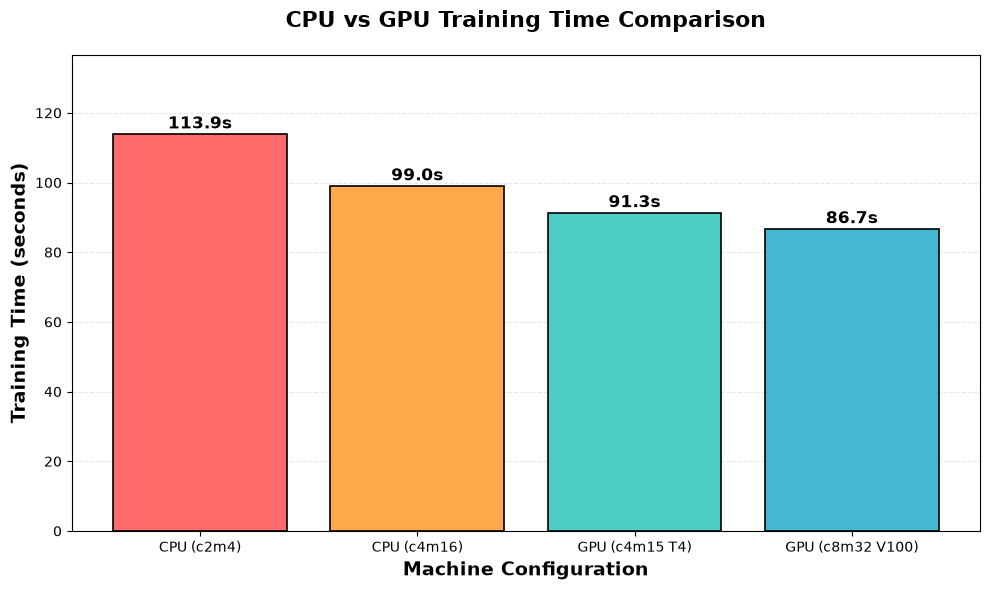

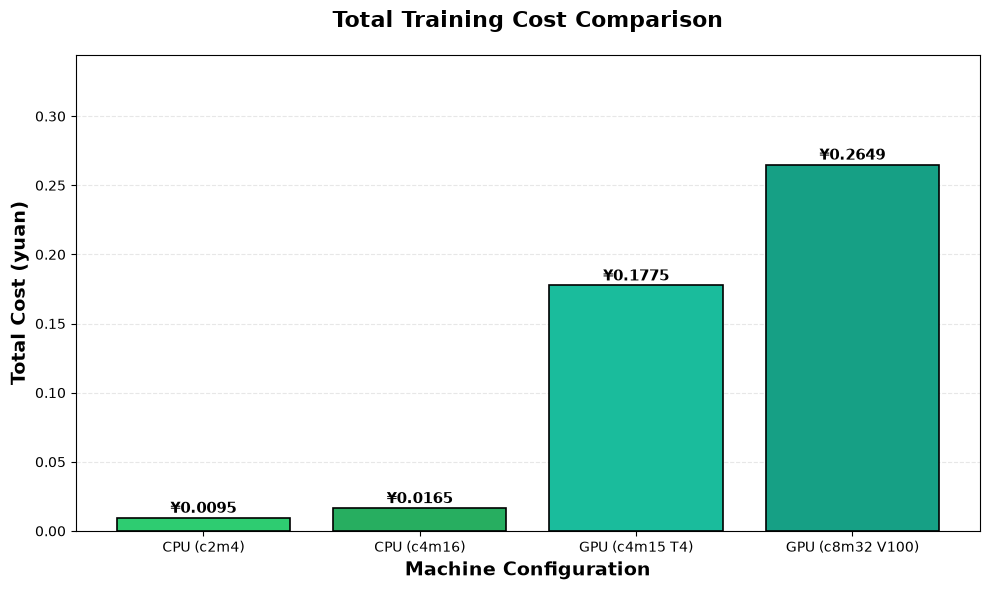

In [102]:
import matplotlib.pyplot as plt
import numpy as np

# TODO: Generate a barchart plot for training time comparison
# x-axis represents machine configuration (e.g., CPU(c2m4), GPU(NVIDIA T4)
# y-axis represents training time in seconds

# 训练时间数据（秒）- 请根据你的实际测试结果替换
# 假设你在不同配置上运行了训练
machine_configs = ['CPU (c2m4)', 'CPU (c4m16)', 'GPU (c4m15 T4)', 'GPU (c8m32 V100)']
training_times = [113.9, 99, 91.3, 86.7]  # 秒 - 替换为你的实际数据

# 创建柱状图
fig, ax = plt.subplots(figsize=(10, 6))

# 颜色设置
colors = ['#FF6B6B', '#FFA94D', '#4ECDC4', '#45B7D1']
bars = ax.bar(machine_configs, training_times, color=colors, edgecolor='black', linewidth=1.2)

# 添加数值标签
for bar, time in zip(bars, training_times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{time:.1f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 设置图表属性
ax.set_ylabel('Training Time (seconds)', fontsize=14, fontweight='bold')
ax.set_xlabel('Machine Configuration', fontsize=14, fontweight='bold')
ax.set_title('CPU vs GPU Training Time Comparison', fontsize=16, fontweight='bold', pad=20)

# 添加网格线
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# 设置 y 轴从 0 开始
ax.set_ylim(0, max(training_times) * 1.2)

# 添加性能提升标注
if len(training_times) >= 2:
    speedup = training_times[0] / training_times[-1]

plt.tight_layout()
plt.show()
# TODO: end

# TODO: Plot machine cost comparison (optional)
# x-axis represents machine type (e.g., CPU(c2m4), GPU(NVIDIA T4)
# y-axis represents total cost in yuan

# 机器配置和价格（元/小时）
# 假设训练时间已在上面的 training_times 中定义
machine_types = ['CPU (c2m4)', 'CPU (c4m16)', 'GPU (c4m15 T4)', 'GPU (c8m32 V100)']
cost_per_hour = [0.3, 0.6, 7, 11]  # 元/小时

# 计算总成本 = 训练时间(小时) × 单价
# 注意：c2m4 是免费节点，成本为 0
training_hours = [t / 3600 for t in training_times]  # 转换为小时
total_costs = [hours * price for hours, price in zip(training_hours, cost_per_hour)]

# 创建柱状图
fig, ax = plt.subplots(figsize=(10, 6))

# 颜色设置（不同深浅的绿色表示成本高低）
cost_colors = ['#2ECC71', '#27AE60', '#1ABC9C', '#16A085']
bars = ax.bar(machine_types, total_costs, color=cost_colors, edgecolor='black', linewidth=1.2)

# 添加数值标签
for bar, cost in zip(bars, total_costs):
    height = bar.get_height()
    if cost > 0.001:  # 避免显示极小值
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'¥{cost:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                '¥0', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 设置图表属性
ax.set_ylabel('Total Cost (yuan)', fontsize=14, fontweight='bold')
ax.set_xlabel('Machine Configuration', fontsize=14, fontweight='bold')
ax.set_title('Total Training Cost Comparison', fontsize=16, fontweight='bold', pad=20)

# 添加网格线
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# 设置 y 轴从 0 开始
ax.set_ylim(0, max(total_costs) * 1.3 if max(total_costs) > 0 else 0.1)

plt.tight_layout()
plt.show()
# TODO: end

### 3.2 task2

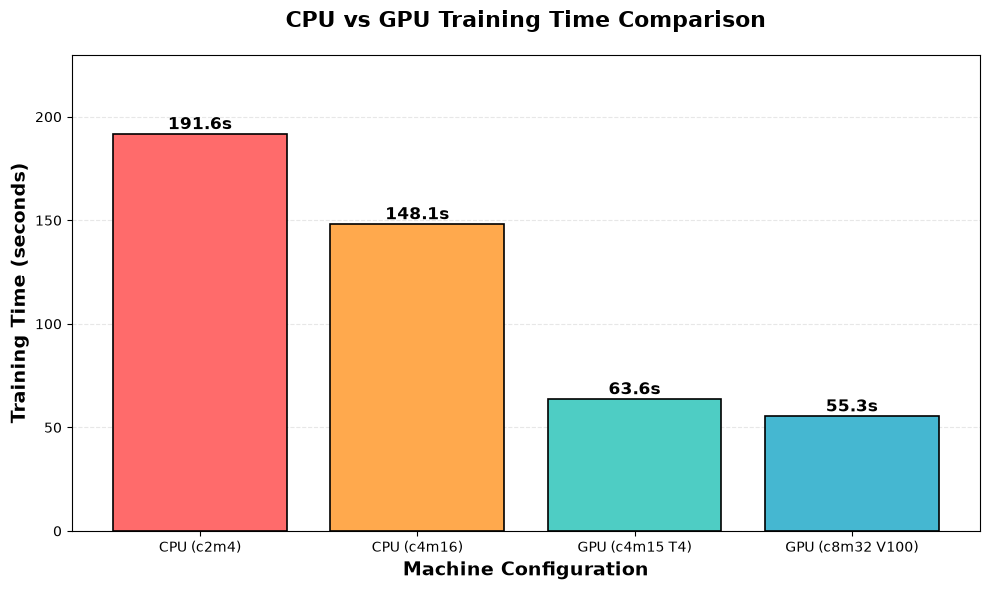

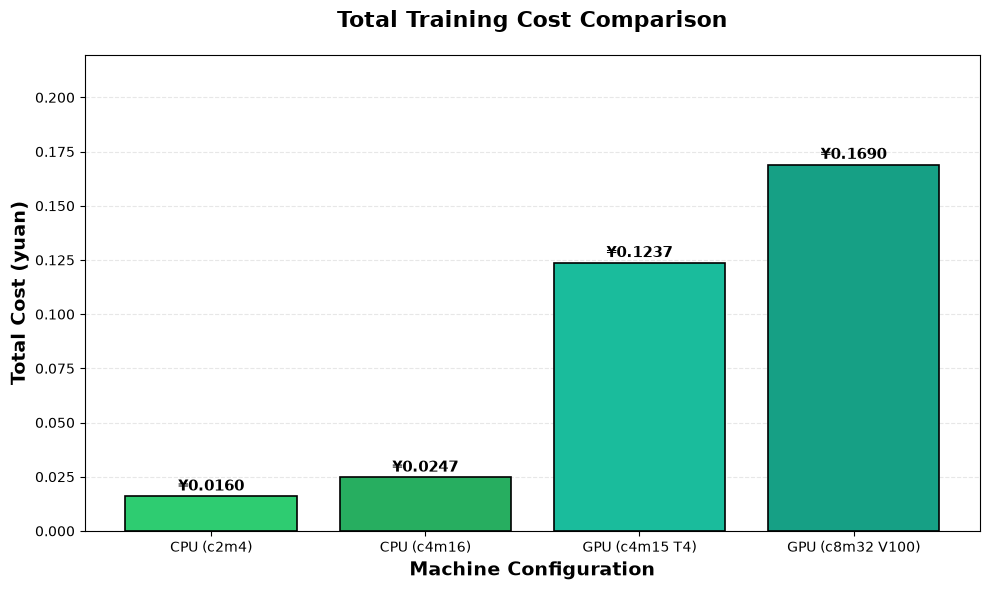

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# TODO: Generate a barchart plot for training time comparison
# x-axis represents machine configuration (e.g., CPU(c2m4), GPU(NVIDIA T4)
# y-axis represents training time in seconds

# 训练时间数据（秒）- 请根据你的实际测试结果替换
# 假设你在不同配置上运行了训练
machine_configs = ['CPU (c2m4)', 'CPU (c4m16)', 'GPU (c4m15 T4)', 'GPU (c8m32 V100)']
training_times = [191.6, 148.1, 63.6, 55.3]  # 秒 - 替换为你的实际数据

# 创建柱状图
fig, ax = plt.subplots(figsize=(10, 6))

# 颜色设置
colors = ['#FF6B6B', '#FFA94D', '#4ECDC4', '#45B7D1']
bars = ax.bar(machine_configs, training_times, color=colors, edgecolor='black', linewidth=1.2)

# 添加数值标签
for bar, time in zip(bars, training_times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{time:.1f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 设置图表属性
ax.set_ylabel('Training Time (seconds)', fontsize=14, fontweight='bold')
ax.set_xlabel('Machine Configuration', fontsize=14, fontweight='bold')
ax.set_title('CPU vs GPU Training Time Comparison', fontsize=16, fontweight='bold', pad=20)

# 添加网格线
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# 设置 y 轴从 0 开始
ax.set_ylim(0, max(training_times) * 1.2)

# 添加性能提升标注
if len(training_times) >= 2:
    speedup = training_times[0] / training_times[-1]

plt.tight_layout()
plt.show()
# TODO: end

# TODO: Plot machine cost comparison (optional)
# x-axis represents machine type (e.g., CPU(c2m4), GPU(NVIDIA T4)
# y-axis represents total cost in yuan

# 机器配置和价格（元/小时）
# 假设训练时间已在上面的 training_times 中定义
machine_types = ['CPU (c2m4)', 'CPU (c4m16)', 'GPU (c4m15 T4)', 'GPU (c8m32 V100)']
cost_per_hour = [0.3, 0.6, 7, 11]  # 元/小时

# 计算总成本 = 训练时间(小时) × 单价
# 注意：c2m4 是免费节点，成本为 0
training_hours = [t / 3600 for t in training_times]  # 转换为小时
total_costs = [hours * price for hours, price in zip(training_hours, cost_per_hour)]

# 创建柱状图
fig, ax = plt.subplots(figsize=(10, 6))

# 颜色设置（不同深浅的绿色表示成本高低）
cost_colors = ['#2ECC71', '#27AE60', '#1ABC9C', '#16A085']
bars = ax.bar(machine_types, total_costs, color=cost_colors, edgecolor='black', linewidth=1.2)

# 添加数值标签
for bar, cost in zip(bars, total_costs):
    height = bar.get_height()
    if cost > 0.001:  # 避免显示极小值
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'¥{cost:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                '¥0', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 设置图表属性
ax.set_ylabel('Total Cost (yuan)', fontsize=14, fontweight='bold')
ax.set_xlabel('Machine Configuration', fontsize=14, fontweight='bold')
ax.set_title('Total Training Cost Comparison', fontsize=16, fontweight='bold', pad=20)

# 添加网格线
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# 设置 y 轴从 0 开始
ax.set_ylim(0, max(total_costs) * 1.3 if max(total_costs) > 0 else 0.1)

plt.tight_layout()
plt.show()
# TODO: end

## Task 4: CNN MNIST


Using device: cpu
MNIST CNN epoch [1/5] | train loss 0.1673, acc 94.92% | test loss 0.0489, acc 98.45%
MNIST CNN epoch [2/5] | train loss 0.0652, acc 98.09% | test loss 0.0435, acc 98.61%
MNIST CNN epoch [3/5] | train loss 0.0473, acc 98.48% | test loss 0.0343, acc 98.82%
MNIST CNN epoch [4/5] | train loss 0.0327, acc 99.00% | test loss 0.0272, acc 99.08%
MNIST CNN epoch [5/5] | train loss 0.0250, acc 99.22% | test loss 0.0230, acc 99.19%


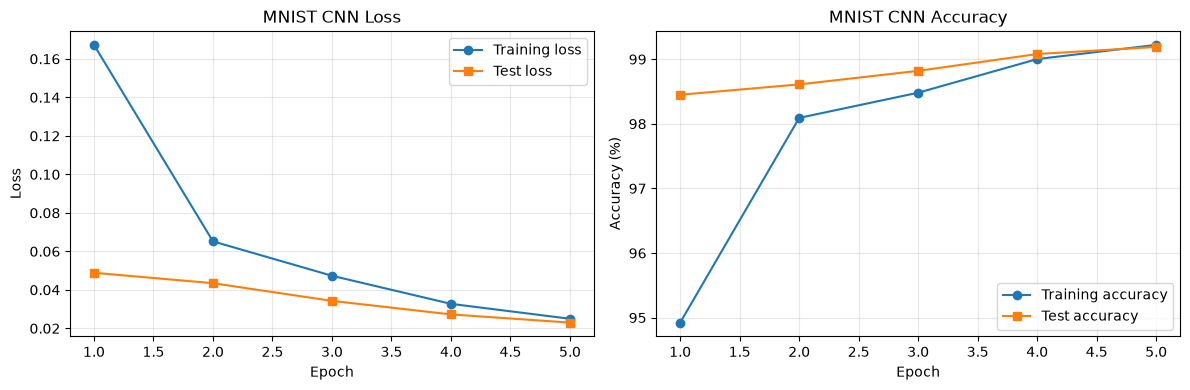

img\init\1.jpg: predicted digit = 1
img\init\2.jpg: predicted digit = 2
img\init\4.jpg: predicted digit = 4
img\init\5.jpg: predicted digit = 5
img\init\6.jpg: predicted digit = 6
img\init\7.jpg: predicted digit = 7


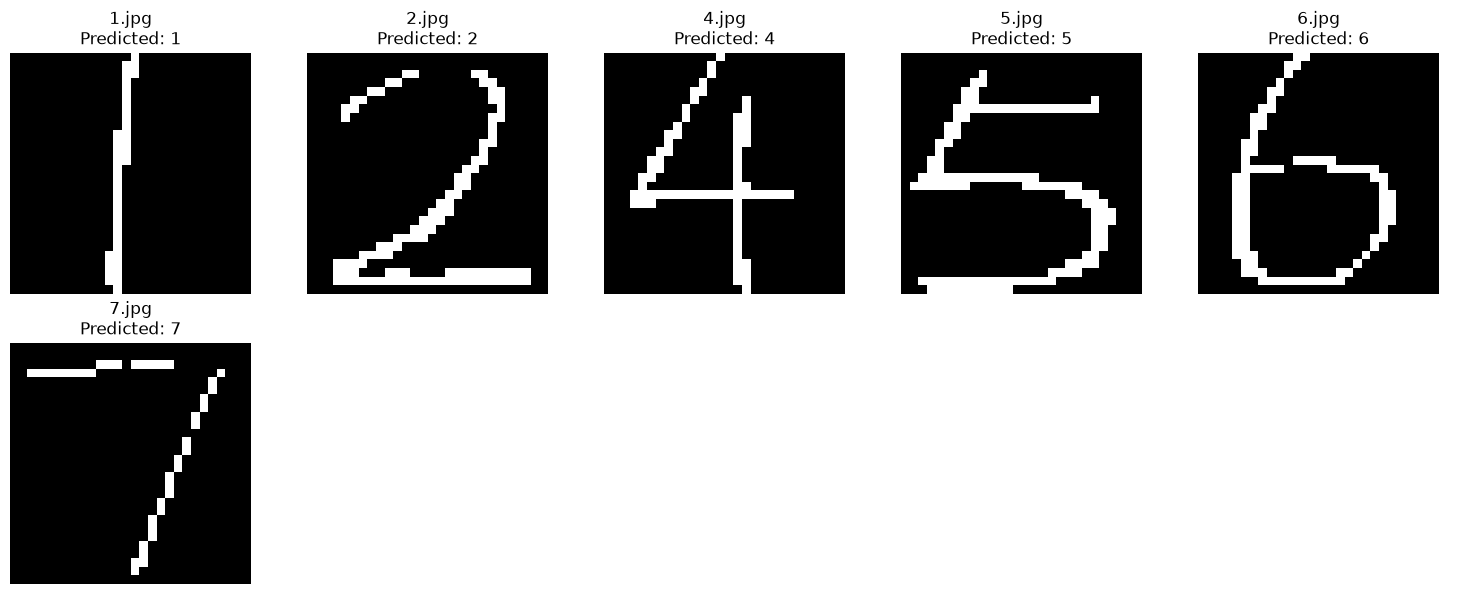

In [104]:
# Task 4: Train a CNN on MNIST and batch-predict images in ./img/init
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


mnist_cnn_device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f'Using device: {mnist_cnn_device}')
mnist_cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_cnn_train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True,
    transform=mnist_cnn_transform
)
mnist_cnn_test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True,
    transform=mnist_cnn_transform
)
mnist_cnn_train_loader = DataLoader(
    mnist_cnn_train_dataset, batch_size=128, shuffle=True
)
mnist_cnn_test_loader = DataLoader(
    mnist_cnn_test_dataset, batch_size=128, shuffle=False
)

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

mnist_cnn_model = MNISTCNN().to(mnist_cnn_device)
mnist_cnn_criterion = nn.CrossEntropyLoss()
mnist_cnn_optimizer = optim.AdamW(
    mnist_cnn_model.parameters(), lr=0.001, weight_decay=1e-4
)
mnist_cnn_epochs = 5
mnist_cnn_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    mnist_cnn_optimizer, T_max=mnist_cnn_epochs
)
mnist_cnn_train_losses, mnist_cnn_test_losses = [], []
mnist_cnn_train_accuracies, mnist_cnn_test_accuracies = [], []

def run_mnist_cnn_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(mnist_cnn_device)
            labels = labels.to(mnist_cnn_device)
            if is_training:
                optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, 100 * correct / total

for epoch in range(mnist_cnn_epochs):
    train_loss, train_accuracy = run_mnist_cnn_epoch(
        mnist_cnn_model, mnist_cnn_train_loader,
        mnist_cnn_criterion, mnist_cnn_optimizer
    )
    test_loss, test_accuracy = run_mnist_cnn_epoch(
        mnist_cnn_model, mnist_cnn_test_loader, mnist_cnn_criterion
    )
    mnist_cnn_scheduler.step()
    mnist_cnn_train_losses.append(train_loss)
    mnist_cnn_test_losses.append(test_loss)
    mnist_cnn_train_accuracies.append(train_accuracy)
    mnist_cnn_test_accuracies.append(test_accuracy)
    print(
        f'MNIST CNN epoch [{epoch + 1}/{mnist_cnn_epochs}] | '
        f'train loss {train_loss:.4f}, acc {train_accuracy:.2f}% | '
        f'test loss {test_loss:.4f}, acc {test_accuracy:.2f}%'
    )
mnist_cnn_epoch_axis = range(1, mnist_cnn_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(mnist_cnn_epoch_axis, mnist_cnn_train_losses, 'o-', label='Training loss')
ax1.plot(mnist_cnn_epoch_axis, mnist_cnn_test_losses, 's-', label='Test loss')
ax1.set(xlabel='Epoch', ylabel='Loss', title='MNIST CNN Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax2.plot(mnist_cnn_epoch_axis, mnist_cnn_train_accuracies, 'o-', label='Training accuracy')
ax2.plot(mnist_cnn_epoch_axis, mnist_cnn_test_accuracies, 's-', label='Test accuracy')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='MNIST CNN Accuracy')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()
mnist_image_dir = Path('./img/init')
mnist_image_paths = sorted(
    path for path in mnist_image_dir.iterdir()
    if path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
)
if not mnist_image_paths:
    raise FileNotFoundError(f'No image files found in {mnist_image_dir}')
mnist_display_images = []
mnist_model_images = []
for image_path in mnist_image_paths:
    image = Image.open(image_path).convert('L')
    image = transforms.Resize((28, 28))(image)
    image_tensor = transforms.ToTensor()(image)
    image_tensor = 1.0 - image_tensor
    image_tensor = (image_tensor > 0.5).float()
    mnist_display_images.append(image_tensor)
    mnist_model_images.append(
        transforms.Normalize((0.1307,), (0.3081,))(image_tensor)
    )
mnist_custom_batch = torch.stack(mnist_model_images).to(mnist_cnn_device)
mnist_cnn_model.eval()
with torch.no_grad():
    mnist_predictions = mnist_cnn_model(mnist_custom_batch).argmax(dim=1).cpu()
columns = min(5, len(mnist_image_paths))
rows = (len(mnist_image_paths) + columns - 1) // columns
fig, axes = plt.subplots(
    rows, columns, figsize=(3 * columns, 3 * rows), squeeze=False
)
axes = axes.ravel()
for index, (image_path, image, prediction) in enumerate(
    zip(mnist_image_paths, mnist_display_images, mnist_predictions.tolist())
):
    axes[index].imshow(image.squeeze(0), cmap='gray', vmin=0, vmax=1)
    axes[index].set_title(f'{image_path.name}\nPredicted: {prediction}')
    axes[index].axis('off')
    print(f'{image_path}: predicted digit = {prediction}')
for index in range(len(mnist_image_paths), len(axes)):
    axes[index].axis('off')
plt.tight_layout()
plt.show()